# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [4]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Draw the room and set up some variables

In [5]:
function [W,F,B,pxx,pyy,vx,vy] = drawRoom(NB,showPlot)
  % Room geometry
  w = 0.2; % thickness of wall
  W = 10;  % width of room
  F = 0.7; % L-shape factor (larger value is more extreme)

  % Base-station location(s)
  switch NB
    case 1
      B = [(1-F)*W/2; W-(1-F)*W/2]; % [x; y]
    case 2
      B = [[(1-F)*W/2 W-(1-F)*W/2]; [(1-F)*W/2 W-(1-F)*W/2]]; % [x1 x2; y1 y2]
    case 3
      B = [[(1-F)*W/2 W-(1-F)*W/2] (1-F)*W/2; ...
           [(1-F)*W/2 W-(1-F)*W/2 W-(1-F)*W/2]]; % [x1 x2 x3; y1 y2 y3]    
  end

  if showPlot
    %% Draw room geometry
    CL = lines; set(gcf,"Color",[1 1 1]);
    axes('Units', 'normalized', 'Position', [0 0 1 1]);
    x1 = [0 0 W W (1-F)*W (1-F)*W 0];
    y1 = [0 W W F*W F*W 0 0];
    x0 = [-w -w W+w W+w (1-F)*W+w (1-F)*W+w -w];
    y0 = [-w W+w W+w F*W-w F*W-w -w -w];
    gray = 0.9;
    fill(x0,y0,gray*[1 1 1]); hold on; 
    fill(x1,y1,'w'); axis square;
    set(gca,"Visible","off"); % This works in MATLAB but not in Octave
    xlim([-2*w W+2*w]); ylim([-2*w W+2*w]);

    %% Plot base station(s)
    plot(B(1,:),B(2,:),'s',"Color",CL(4,:),"MarkerSize",20,"LineWidth",3,...
       "MarkerFaceColor",CL(4,:));
  end

  %% Robot trajectory: compute true velocity profile (plus initial point)
  % f = fraction of min thickness; o = offset because of that
  f = 0.2; o = f*(1-F)*W;
  % Path = (o,o) ... (o,W-o) ... (W-o,W-o) ... (W-o,(F*W)+o) ...
  %        ((1-F)*W)-o,(F*W)+o) ... ((1-F)*W)-o,o) ... (o,o)
  px = [o o W-o W-o (1-F)*W-o (1-F)*W-o o];
  py = [o W-o W-o F*W+o F*W+o o o];

  % compute velocity profile of robot... update about every dx m
  vx = 0; vy = 0; dx = 0.1;
  for theS = 1:length(px)-1 % path segment
    len = ceil(sqrt((px(theS+1)-px(theS))^2 + (py(theS+1)-py(theS))^2)/dx);
    % compute (x,y) points along this line segment, then velocities
    pxx = linspace(0,1,len)*(px(theS+1)-px(theS)) + px(theS);
    pyy = linspace(0,1,len)*(py(theS+1)-py(theS)) + py(theS);
    vx = [vx; diff(pxx)']; vy = [vy; diff(pyy)'];
  end
  pxx = px(1)+cumsum(vx); pyy = py(1)+cumsum(vy); 
  if showPlot, plot(pxx,pyy,'k--'); end
end

### Compute the number of walls between two points

In [6]:
function NW = numWalls(p1,p2,F,W)
  NW = 0;
  % Calculate slope (m) and intercept (b) of (infinite-length) line 
  % passing through this particle and this base station
  m = (p1(2)-p2(2))/(p1(1)-p2(1));
  b = p2(2)-m*p2(1);

  % Check to see if line *segment* passes through the horizontal wall
  if abs(m)<eps % "x" location where line passes through y=F*W
    x = Inf;
  else
    x = (F*W-b)/m; 
  end
  condX = x > min(p1(1),p2(1)) && x < max(p1(1),p2(1));
  if condX && x > (1-F)*W && x < W % if intersection point is between 
    NW = 1;             % "x" endpoints of both lines
  end

  % Check to see if line *segment* passes through the vertical wall
  y = m*(1-F)*W+b; % "y" location where line passes through x=(1-F)*W
  condY = y > min(p1(2),p2(2)) && y < max(p1(2),p2(2));
  if condY && y > 0 && y < F*W         % if intersection point is between 
    NW = NW + 1; % "y" endpoints of both lines
  end
end

### Implement the particle filter for the indoor-navigation problem

Completed iteration 25 out of 348.
Completed iteration 50 out of 348.
Completed iteration 75 out of 348.
Completed iteration 100 out of 348.
Completed iteration 125 out of 348.
Completed iteration 150 out of 348.
Completed iteration 175 out of 348.
Completed iteration 200 out of 348.
Completed iteration 225 out of 348.
Completed iteration 250 out of 348.
Completed iteration 275 out of 348.
Completed iteration 300 out of 348.
Completed iteration 325 out of 348.
Done! Now preparing scatter plot.


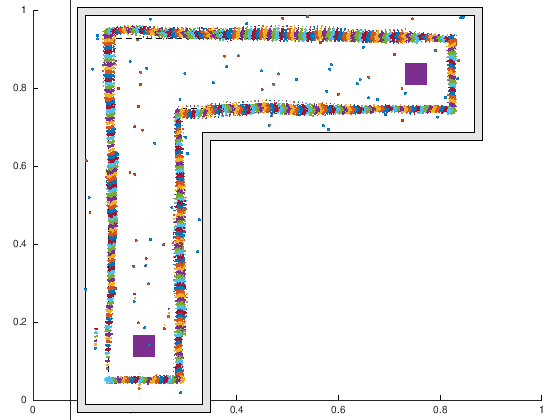

In [15]:
% You can set the variable "showPlot" to zero to speed up simulation.
showPlot = 1;

% Set the number of base stations to use
NB = 2; 
% NB = 3; 
% NB = 1;

% Set up some variables and draw the room
[W,F,B,pxx,pyy,vx,vy] = drawRoom(NB,showPlot);

% Select the method for approximating f(x{k}|x{k-1})
% fxxMethod = "sigma-point";
fxxMethod = "coordinateTx";

% Set random-number-generator initial states for consistent results
rand("state",1);  randn("state",1);

%% Randomly generate initial particles and plot them
%  Room shape = +----------+      Modified shape = +-----+----------+
%               |   TOP    |                       | BOT |   TOP    |
%               |----+-----+                       +-----+----------+
%               |    |                                   0
%               |    |
%               +----+
%
% "Cut off" bottom portion and "glue on" to top portion (via a
% rotation) to generate random points. Then, any random points that have
% "x" coordinate less than zero belong in the bottom portion and get
% translated/rotated into that portion
NP = 100; % number of particles
P = [W; W] - diag([(1+F)*W, (1-F)*W])*rand([2,NP]); % points in mod. shape
P(:,(P(1,:)<0)) = [W; 0] - [0 1; 1 0]*P(:,(P(1,:)<0)); % translate 
if showPlot
  CL = lines; scatter(P(1,:),P(2,:),30,CL(1,:),"filled");
end

%% Set up some constants for the filter
WW    = ones(1,NP)/NP; % weights for each particle, random
nEffR = 0.8*NP;   % threshold before we resample particles

sS    = 0.005;    % standard deviation of speed error
sQ    = 5*pi/180; % standard deviation of angle error
dT    = 1;        % time between samples

L1    = 36;       % path loss at 1m, in dB
LW    = 16;       % path loss per wall, in dB
sFade = 1;        % standard deviation of log-normal fading in dB

pxxHat = 0*pxx; pyyHat = 0*pyy;
for theStep = 1:length(vx)
  % Make (noisy) zk measurement at the vehicle
  loc = [pxx(theStep); pyy(theStep)]; % true vehicle (x,y) location
  z = zeros(NB,1);
  for theB = 1:NB
    dist = norm(loc - B(:,theB));
    NW = numWalls(loc,B(:,theB),F,W);
    z(theB) = 36+20*log10(dist)+16*NW + sFade*randn(1);
  end
  
  % Make (noisy) speed and angle measurement "uk" at the vehicle
  sm = norm([vx(theStep); vy(theStep)]) + sS*randn(1); 
  qm = atan2(vy(theStep), vx(theStep))  + sQ*randn(1);
  
  % Convert (noisy) speed/angle measurement to cartesian
  % Conversion doesn't improve vx/vy estimates much, but does at least
  % provide a good covariance matrix for the vx/vy estimates
  switch fxxMethod
    case "sigma-point" % Use sigma-point method from Lesson 3.2.2, except 
      % use CKF scaling values
      Sw = diag([sS sQ]); WV = sqrt(2)*[Sw -Sw];
      VX = [(sm - WV(1,:)).*cos(qm-WV(2,:)); (sm - WV(1,:)).*sin(qm-WV(2,:))];
      VXhat = sum(VX,2)/4; vxhat = VXhat(1); vyhat = VXhat(2);
      Sa = (VX - VXhat)*(VX - VXhat)'/4;
    case "coordinateTx" % Use polar-to-cartesian method from Lesson 2.4.2
      vxhat = sm.*cos(qm)*(1-exp(-sQ^2)+exp(-sQ^2/2));
      vyhat = sm.*sin(qm)*(1-exp(-sQ^2)+exp(-sQ^2/2));  
      S11a = sm.^2*exp(-2*sQ^2).*((cos(qm)).^2.*(cosh(2*sQ^2)-cosh(sQ^2)) ...
             +(sin(qm)).^2.*(sinh(2*sQ^2)-sinh(sQ^2))) ...
             +sS^2*exp(-2*sQ^2)*((cos(qm)).^2.*(2*cosh(2*sQ^2)-cosh(sQ^2)) ...
             +(sin(qm)).^2.*(2*sinh(2*sQ^2)-sinh(sQ^2)));
      S12a = sin(qm).*cos(qm).*exp(-4*sQ^2).*(sS^2+(sm.^2+sS^2)*(1-exp(sQ^2)));
      S22a = sm.^2*exp(-2*sQ^2).*((sin(qm)).^2.*(cosh(2*sQ^2)-cosh(sQ^2)) ...
             +(cos(qm)).^2.*(sinh(2*sQ^2)-sinh(sQ^2)))...
             +sS^2*exp(-2*sQ^2)*((sin(qm)).^2.*(2*cosh(2*sQ^2)-cosh(sQ^2))...
             +(cos(qm)).^2.*(2*sinh(2*sQ^2)-sinh(sQ^2)));
      Sa = [S11a S12a; S12a S22a];
    otherwise
      error("Unknown fxxMethod");
  end

  % Update particles  
  for theP = 1:NP
    % Randomly generate new particle location... sample q(xk|xk-1)
    P(:,theP) = P(:,theP) + [vxhat; vyhat] + chol(Sa,"lower")*randn(2,1);
      
    % Choose to constrain if estimates hit main outside walls
    P(1,theP) = max(0,P(1,theP)); P(1,theP) = min(W,P(1,theP));
    P(2,theP) = max(0,P(2,theP)); P(2,theP) = min(W,P(2,theP));
        
    % Compute f(zk|xk)
    fz = 1; % initialize... fz = product of each measurement prob.
    for theB = 1:NB
      dist = norm(P(:,theP) - B(:,theB));
      NW = numWalls(P(:,theP),B(:,theB),F,W);
      fz = fz * normpdf(z(theB),L1+20*log10(dist)+LW*NW,sFade);
     end
    WW(theP) = WW(theP) * fz; % compute unnormalized weight
  end
  WW = WW/sum(WW); % normalize the weights

  if showPlot
    scatter(P(1,:),P(2,:),100*WW+1,CL(1+mod(theStep,63),:),"filled");
  end
  
  % Maybe resample the particles
  nEff = 1/sum(WW.^2); % Actual number of "effective" particles
  if nEff<nEffR % check to see if this is below the "resample" threshold
    iPick  = 1; Pnew  = zeros(2,NP); c = cumsum(WW); % initialize
    threshold = rand(1)/NP;
    for cp=1:NP
      while threshold>c(iPick) && iPick<NP
        iPick = iPick + 1; 
      end
      Pnew(:,cp) = P(:,iPick);
      threshold = threshold + 1/NP;                
    end
    P = Pnew; % the new set of particles
    WW = ones(1,NP)/NP; % the new weights
  end           
  Phat = P*WW';
  pxxHat(theStep) = Phat(1); pyyHat(theStep) = Phat(2);
    
  if mod(theStep,25)==0,
    fprintf('Completed iteration %d out of %d.\n',theStep,length(vx));
  end
end
if showPlot
  fprintf('Done! Now preparing scatter plot.\n');
else
  fprintf('Done!\n');
end

### Compute root-mean-squared error between actual and estimated position

In [16]:
posnErr = [pxx,pyy] - [pxxHat,pyyHat]; % The position error in (x,y) coordinates
errDist = sqrt(posnErr(:,1).^2 + posnErr(:,2).^2); % The position error as a distance
fprintf('RMS position error = %g\n',rms(errDist)); % The RMS position error

RMS position error = 0.164631
